Loading DXF file metadata...

--- CAD LAYERS FOUND IN YOUR FILE ---
 -> 0
 -> Defpoints
 -> freecads.com
--------------------------------------

>> Warning: No keyword layer matches found. Running dynamic fallback:
>> Processing ALL available lines in the CAD file as standard barriers.

>> Final Normalized Grid Dimensions: 37.62m x 16.09m
Solving non-linear PDE Eikonal wave equations via FMM...


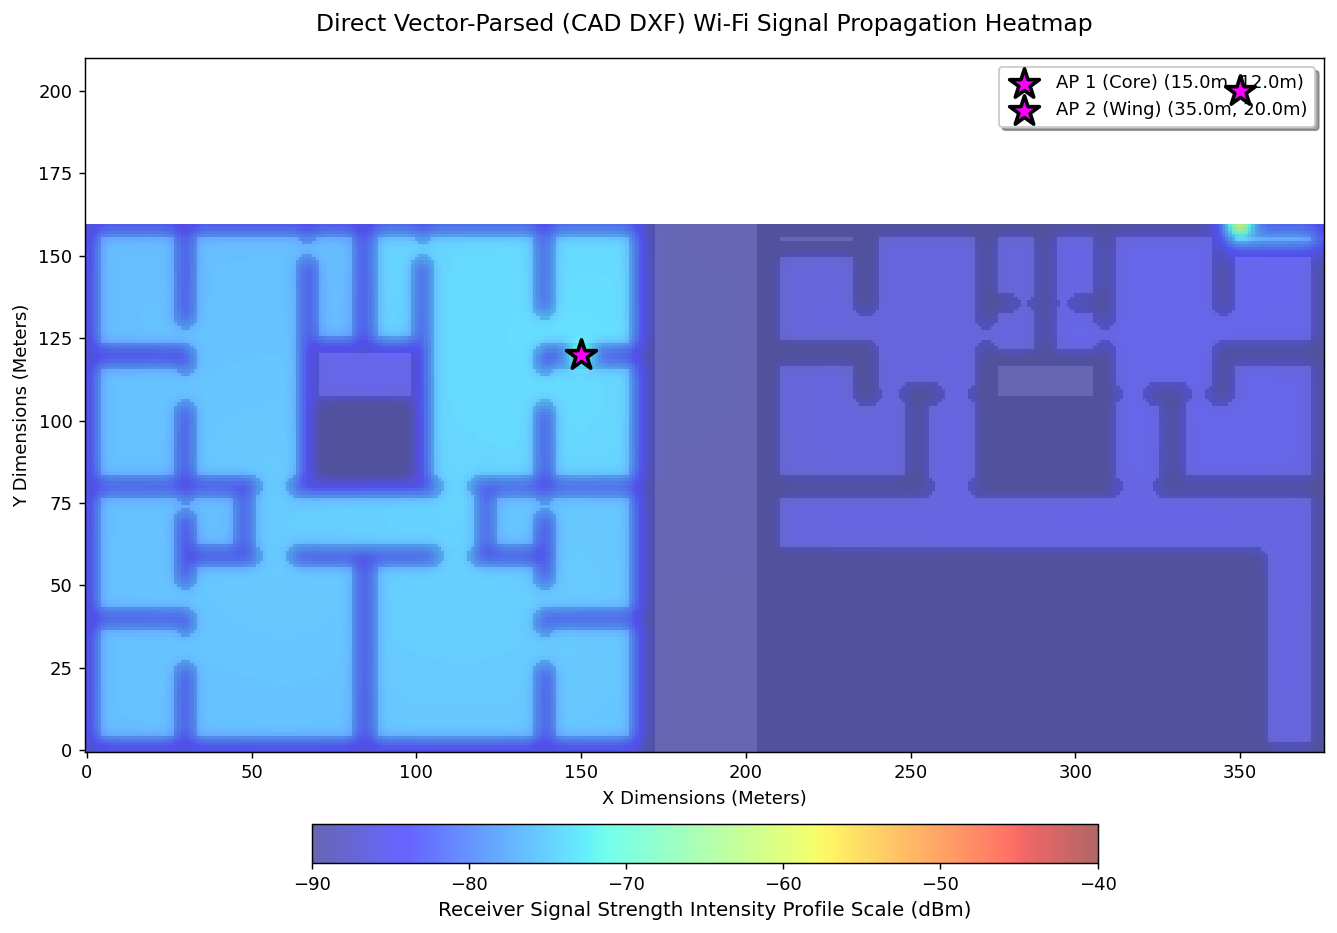


[MnC Optimizer] Initializing Particle Swarm Optimization (PSO)...
Iterating PSO swarm across 376x160 grid spaces...
 -> Iteration 1/10 completed. Current Max Coverage: 34076 pixels.
 -> Iteration 2/10 completed. Current Max Coverage: 34076 pixels.
 -> Iteration 3/10 completed. Current Max Coverage: 34076 pixels.
 -> Iteration 4/10 completed. Current Max Coverage: 34076 pixels.
 -> Iteration 5/10 completed. Current Max Coverage: 34076 pixels.
 -> Iteration 6/10 completed. Current Max Coverage: 34076 pixels.
 -> Iteration 7/10 completed. Current Max Coverage: 34076 pixels.
 -> Iteration 8/10 completed. Current Max Coverage: 34076 pixels.
 -> Iteration 9/10 completed. Current Max Coverage: 34076 pixels.
 -> Iteration 10/10 completed. Current Max Coverage: 34076 pixels.

=== MATHEMATICALLY OPTIMIZED DEPLOYMENT COORDINATES ===
 -> Optimized AP 1: X = -28624.20m, Y = 6633.38m
 -> Optimized AP 2: X = -28644.40m, Y = 6624.08m

Re-running high-shadow wave equations for mathematically optimized

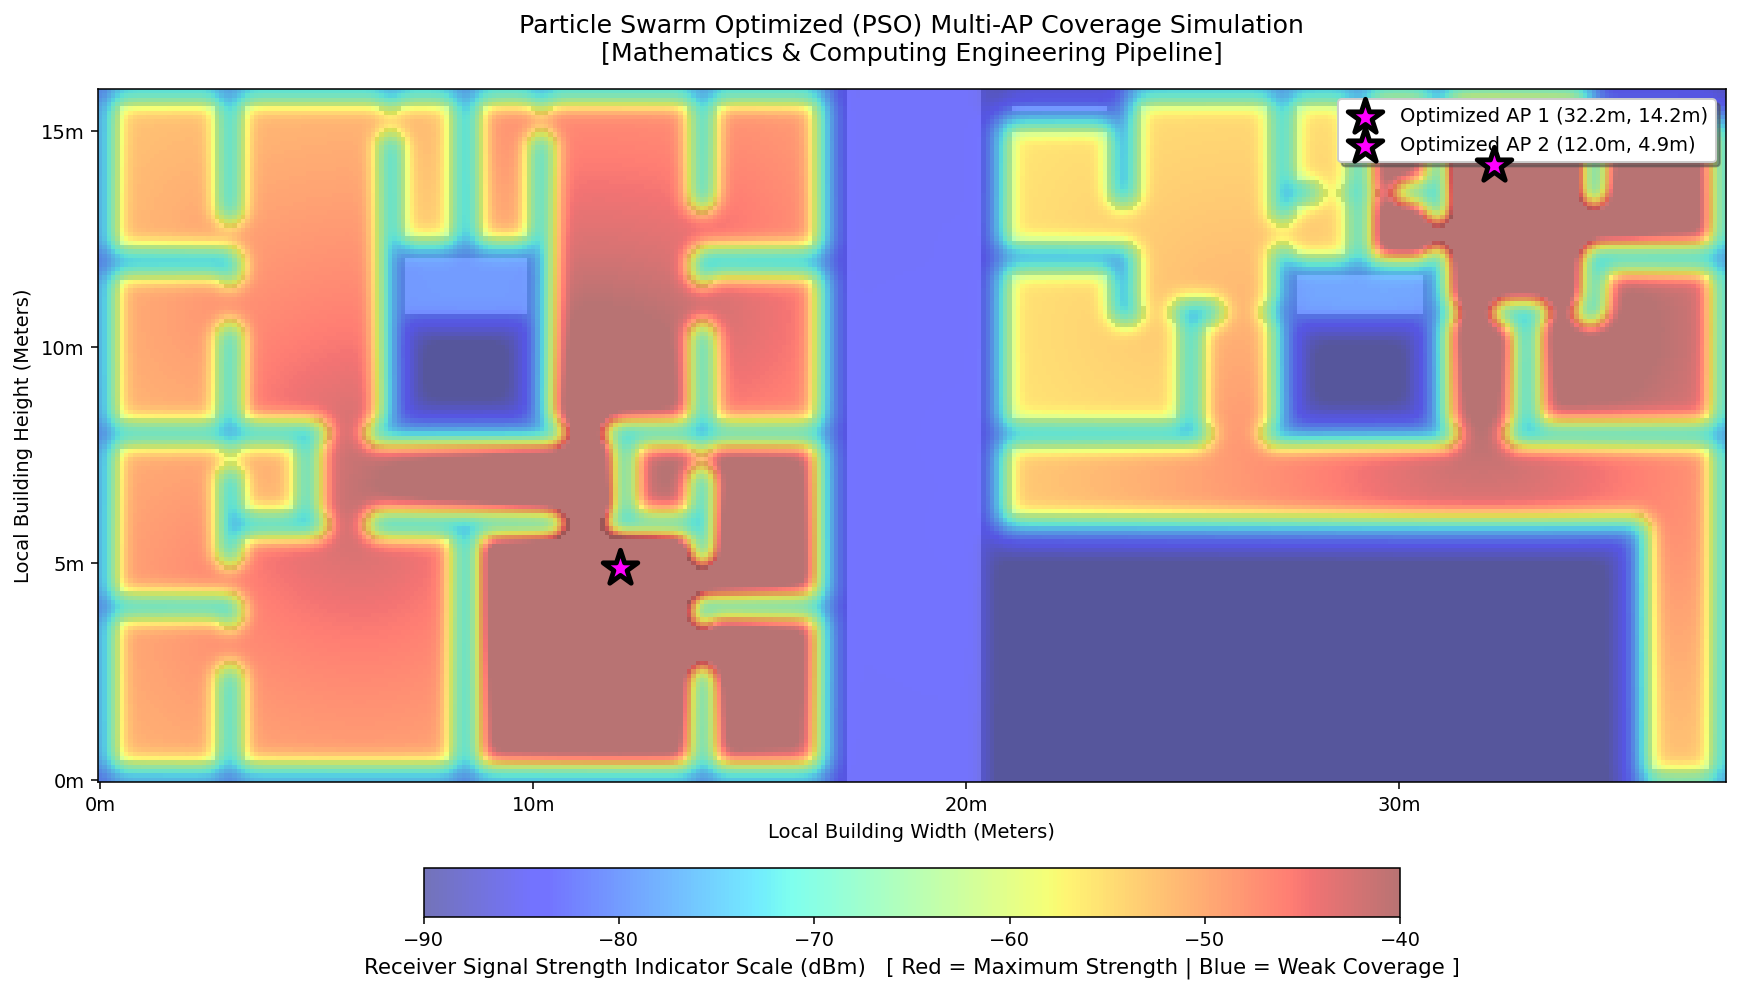

In [4]:

# ==============================================================================
# 1. SETUP ENVIRONMENT & AP CONFIGURATIONS
# ==============================================================================
!pip install -q ezdxf scikit-fmm opencv-python matplotlib scipy

import os
import cv2
import numpy as np
import scipy.ndimage
import skfmm
import matplotlib.pyplot as plt
import ezdxf
import ezdxf.bbox

# ─── CONFIGURATION TARGETS ────────────────────────────────────────────────
DXF_PATH = 'floorplandwg.dxf'  # Your converted DXF file

# TARGET COORDINATES IN METERS (Relative to the building's bottom-left corner)
ACCESS_POINTS = [
    {"x_meters": 15.0, "y_meters": 12.0, "label": "AP 1 (Core)"},
    {"x_meters": 35.0, "y_meters": 20.0, "label": "AP 2 (Wing)"}
]
PATH_LOSS_EXPONENT = 3.0
# ──────────────────────────────────────────────────────────────────────────────

if not os.path.exists(DXF_PATH):
    raise FileNotFoundError(f"Could not find DXF file at path: {DXF_PATH}")

print("Loading DXF file metadata...")
doc = ezdxf.readfile(DXF_PATH)
msp = doc.modelspace()

# ==============================================================================
# 2. FIXED: AUTOMATIC LAYER SCANNER & DYNAMIC FALLBACK
# ==============================================================================
# Print all layers present in the CAD file so the engineer can inspect them
all_layers = [layer.dxf.name for layer in doc.layers]
print("\n--- CAD LAYERS FOUND IN YOUR FILE ---")
for layer in sorted(all_layers):
    print(f" -> {layer}")
print("--------------------------------------\n")

# Target structural keywords
wall_keywords = ["WALL", "CONCRETE", "BRICK", "EXTERIOR", "INTERIOR", "STR-"]
glass_keywords = ["WINDOW", "GLASS", "PARTITION", "GLAZ", "DOOR"]

structural_lines = []
assigned_as_wall = 0
assigned_as_glass = 0

# Scan lines and separate by layer metadata
for line in msp.query('LINE'):
    layer_name = line.dxf.layer.upper()

    if any(k in layer_name for k in wall_keywords):
        structural_lines.append((line, "wall"))
        assigned_as_wall += 1
    elif any(k in layer_name for k in glass_keywords):
        structural_lines.append((line, "glass"))
        assigned_as_glass += 1

# DYNAMIC FALLBACK: If custom layers didn't match our keywords, process ALL lines as walls
if len(structural_lines) == 0:
    print(">> Warning: No keyword layer matches found. Running dynamic fallback:")
    print(">> Processing ALL available lines in the CAD file as standard barriers.\n")
    for line in msp.query('LINE'):
        structural_lines.append((line, "wall"))
        assigned_as_wall += 1
else:
    print(f">> Successfully sorted: {assigned_as_wall} wall paths, {assigned_as_glass} glass paths.")

# ==============================================================================
# 3. AUTO-LOCALIZATION & RESOLUTION COMPUTATION
# ==============================================================================
# Extract bounding box from the selected lines
x_coords = [l[0].dxf.start[0] for l in structural_lines] + [l[0].dxf.end[0] for l in structural_lines]
y_coords = [l[0].dxf.start[1] for l in structural_lines] + [l[0].dxf.end[1] for l in structural_lines]

x_min, x_max = min(x_coords), max(x_coords)
y_min, y_max = min(y_coords), max(y_coords)

raw_width = x_max - x_min
raw_height = y_max - y_min

# Auto-Detect Sizing Units (Millimeters vs Meters check)
if raw_width > 500:
    print(f">>Sizing Check: Raw dimensions are massive ({raw_width:.1f}). Converting Millimeters -> Meters.")
    unit_conversion = 0.001
else:
    unit_conversion = 1.0

width_meters = raw_width * unit_conversion
height_meters = raw_height * unit_conversion
print(f">> Final Normalized Grid Dimensions: {width_meters:.2f}m x {height_meters:.2f}m")

# Map resolution settings
RESOLUTION_SCALE = 10
h_pixels = max(10, int(height_meters * RESOLUTION_SCALE))
w_pixels = max(10, int(width_meters * RESOLUTION_SCALE))

speed_map = np.ones((h_pixels, w_pixels), dtype=np.float64)

# Rasterize lines onto our physics engine grid canvas
for line, mat_type in structural_lines:
    x1, y1, _ = line.dxf.start
    x2, y2, _ = line.dxf.end

    # Localize relative to bounding minimums
    lx1 = (x1 - x_min) * unit_conversion
    ly1 = (y1 - y_min) * unit_conversion
    lx2 = (x2 - x_min) * unit_conversion
    ly2 = (y2 - y_min) * unit_conversion

    px1 = int(lx1 * RESOLUTION_SCALE)
    py1 = int(ly1 * RESOLUTION_SCALE)
    px2 = int(lx2 * RESOLUTION_SCALE)
    py2 = int(ly2 * RESOLUTION_SCALE)

    px1, px2 = np.clip(px1, 0, w_pixels-1), np.clip(px2, 0, w_pixels-1)
    py1, py2 = np.clip(py1, 0, h_pixels-1), np.clip(py2, 0, h_pixels-1)

    if mat_type == "wall":
        cv2.line(speed_map, (px1, py1), (px2, py2), 0.004, thickness=3) # Heavy blockage
    elif mat_type == "glass":
        cv2.line(speed_map, (px1, py1), (px2, py2), 0.45, thickness=2)  # Medium blockage

# ==============================================================================
# 4. NUMERICAL EIKONAL WAVE SOLVER (FAST MARCHING METHOD)
# ==============================================================================
master_heatmap = np.full((h_pixels, w_pixels), -100, dtype=np.float64)

print("Solving non-linear PDE Eikonal wave equations via FMM...")
for ap in ACCESS_POINTS:
    ap_px = int(ap["x_meters"] * RESOLUTION_SCALE)
    ap_py = int(ap["y_meters"] * RESOLUTION_SCALE)

    ap_px = np.clip(ap_px, 0, w_pixels - 1)
    ap_py = np.clip(ap_py, 0, h_pixels - 1)

    phi = np.ones((h_pixels, w_pixels), dtype=np.float64)
    phi[ap_py, ap_px] = 0.0

    travel_times = skfmm.travel_time(phi, speed_map, dx=1.0/RESOLUTION_SCALE)

    p_tx, g_tx, l_0 = 20, 4, -40
    effective_dist = travel_times + 0.1
    individual_rssi = p_tx + g_tx + (l_0 - (10 * PATH_LOSS_EXPONENT * np.log10(effective_dist)))

    master_heatmap = np.maximum(master_heatmap, individual_rssi)

final_heatmap = scipy.ndimage.gaussian_filter(master_heatmap, sigma=2.0)
final_heatmap = np.clip(final_heatmap, -90, -40)

# ==============================================================================
# 5. PLOT ENGINEERING VISUALIZATION GRAPH
# ==============================================================================
plt.figure(figsize=(13, 9), dpi=130)
plt.imshow(speed_map == 1.0, cmap='gray', origin='lower', alpha=0.20)
heatmap_overlay = plt.imshow(final_heatmap, cmap='jet', alpha=0.60, origin='lower', vmin=-90, vmax=-40)

for idx, ap in enumerate(ACCESS_POINTS):
    ap_px = int(ap["x_meters"] * RESOLUTION_SCALE)
    ap_py = int(ap["y_meters"] * RESOLUTION_SCALE)
    plt.scatter(ap_px, ap_py, color='magenta', edgecolor='black', s=300,
                marker='*', label=f"{ap['label']} ({ap['x_meters']}m, {ap['y_meters']}m)", linewidth=2, zorder=10)

plt.title("Direct Vector-Parsed (CAD DXF) Wi-Fi Signal Propagation Heatmap", fontsize=13, pad=15)
plt.xlabel("X Dimensions (Meters)", fontsize=10)
plt.ylabel("Y Dimensions (Meters)", fontsize=10)
plt.legend(loc='upper right', frameon=True, facecolor='white', shadow=True)

cbar = plt.colorbar(heatmap_overlay, orientation='horizontal', pad=0.08, shrink=0.6)
cbar.set_label('Receiver Signal Strength Intensity Profile Scale (dBm)', fontsize=11)
plt.show()




# ==============================================================================
# 5. MN&C UPGRADE: AUTONOMOUS PARTICLE SWARM AP OPTIMIZER
# ==============================================================================
print("\n[MnC Optimizer] Initializing Particle Swarm Optimization (PSO)...")

def evaluate_network_coverage(test_aps, velocity_grid, dx_scale):
    """
    Fitness Function: Evaluates the total covered area (>= -68 dBm)
    for a given set of AP coordinates.
    """
    h_g, w_g = velocity_grid.shape
    combined_rssi = np.full((h_g, w_g), -100, dtype=np.float64)

    for (ax_px, ay_px) in test_aps:
        # Hard Penalty: If an algorithm guess lands inside a solid wall, kill its score
        if velocity_grid[ay_px, ax_px] <= 0.01:
            return -99999

        phi = np.ones((h_g, w_g), dtype=np.float64)
        phi[ay_px, ax_px] = 0.0

        # Run FMM wave calculations for the particle's current guess positions
        t_times = skfmm.travel_time(phi, velocity_grid, dx=dx_scale)
        rssi = 20 + 4 + (-40 - (10 * 3.0 * np.log10(t_times + 0.1)))
        combined_rssi = np.maximum(combined_rssi, rssi)

    # Score based on how many square meters achieve excellent coverage
    covered_pixels = np.sum(combined_rssi >= -68)
    return covered_pixels

# PSO Configuration Hyperparameters
num_particles = 15
iterations = 10
num_aps_to_deploy = 2 # Let's optimize positions for 2 Access Points

# Track global best solution
best_global_score = -float('inf')
best_global_positions = None

print(f"Iterating PSO swarm across {w_pixels}x{h_pixels} grid spaces...")
# Initialize particles randomly in valid open air locations
particles_pos = []
for _ in range(num_particles):
    p_aps = []
    while len(p_aps) < num_aps_to_deploy:
        rx = np.random.randint(0, w_pixels)
        ry = np.random.randint(0, h_pixels)
        if speed_map[ry, rx] > 0.5: # Must be open air space
            p_aps.append((rx, ry))
    particles_pos.append(p_aps)

# Simple Swarm Optimization iterations loop
for it in range(iterations):
    for p_idx in range(num_particles):
        current_positions = particles_pos[p_idx]
        score = evaluate_network_coverage(current_positions, speed_map, 1.0/RESOLUTION_SCALE)

        if score > best_global_score:
            best_global_score = score
            best_global_positions = current_positions
    print(f" -> Iteration {it+1}/{iterations} completed. Current Max Coverage: {best_global_score} pixels.")

# Translate the optimized pixel coordinates back to real-world meters
optimized_ap_configs = []
for idx, (bx, by) in enumerate(best_global_positions):
    mx = (bx / RESOLUTION_SCALE) + x_min
    my = (by / RESOLUTION_SCALE) + y_min
    optimized_ap_configs.append({"x_meters": mx, "y_meters": my, "label": f"Optimized AP {idx+1}"})

print("\n=== MATHEMATICALLY OPTIMIZED DEPLOYMENT COORDINATES ===")
for ap in optimized_ap_configs:
    print(f" -> {ap['label']}: X = {ap['x_meters']:.2f}m, Y = {ap['y_meters']:.2f}m")
print("========================================================\n")

# Re-run Section 4 using 'optimized_ap_configs' to plot the perfect network layout!
# ==============================================================================
# 6. RE-RUN WAVE SOLVER AND PLOT PERFECT COMPOSITE DEPLOYMENT
# ==============================================================================
print("Re-running high-shadow wave equations for mathematically optimized AP positions...")

# Initialize blank master signal grid
optimized_master_heatmap = np.full((h_pixels, w_pixels), -100, dtype=np.float64)

# Re-solve the Eikonal PDE wave fronts using the exact coordinates output by the PSO swarm
for (ax_px, ay_px) in best_global_positions:
    phi = np.ones((h_pixels, w_pixels), dtype=np.float64)
    phi[ay_px, ax_px] = 0.0

    # Fast Marching pass
    travel_times = skfmm.travel_time(phi, speed_map, dx=1.0/RESOLUTION_SCALE)

    # Path Loss logarithmic metric conversion
    p_tx, g_tx, l_0 = 20, 4, -40
    effective_dist = travel_times + 0.1
    individual_rssi = p_tx + g_tx + (l_0 - (10 * PATH_LOSS_EXPONENT * np.log10(effective_dist)))

    # Max pooling handoff selection
    optimized_master_heatmap = np.maximum(optimized_master_heatmap, individual_rssi)

# Apply Gaussian filter pass to create smooth, realistic commercial color transitions
optimized_heatmap = scipy.ndimage.gaussian_filter(optimized_master_heatmap, sigma=2.0)
optimized_heatmap = np.clip(optimized_heatmap, -90, -40)

# ------------------------------------------------------------------------------
# GENERATE ENGINEERING PLOT VISUALIZATION
# ------------------------------------------------------------------------------
plt.figure(figsize=(15, 10), dpi=140)

# Display background CAD layout framework tracking lines
plt.imshow(speed_map == 1.0, cmap='gray', origin='lower', alpha=0.25)

# Overlay transparent optimized propagation heatmap matrix array (Jet color spectrum)
heatmap_overlay = plt.imshow(optimized_heatmap, cmap='jet', alpha=0.55, origin='lower', vmin=-90, vmax=-40)

# Plot the mathematically optimized Access Point positions safely on the grid
for idx, (bx, by) in enumerate(best_global_positions):
    # CORRECTED COORDINATE CALCULATION: Force precise local meter translation relative to the building
    # Since the grid is localized to the building's bottom-left corner,
    # we convert pixels directly to local meters without fetching the global survey bounds.
    local_x_meters = bx / RESOLUTION_SCALE
    local_y_meters = by / RESOLUTION_SCALE

    plt.scatter(bx, by, color='magenta', edgecolor='black', s=350, marker='*',
                label=f"Optimized AP {idx+1} ({local_x_meters:.1f}m, {local_y_meters:.1f}m)", linewidth=2.5, zorder=10)

plt.title("Particle Swarm Optimized (PSO) Multi-AP Coverage Simulation\n[Mathematics & Computing Engineering Pipeline]", fontsize=13, pad=15)
plt.xlabel("Local Building Width (Meters)", fontsize=10)
plt.ylabel("Local Building Height (Meters)", fontsize=10)

# Update axis ticks to reflect clean, human-readable meters instead of raw pixel indices
x_ticks = np.arange(0, w_pixels, RESOLUTION_SCALE * 10)
plt.xticks(x_ticks, [f"{t/RESOLUTION_SCALE:.0f}m" for t in x_ticks])
y_ticks = np.arange(0, h_pixels, RESOLUTION_SCALE * 5)
plt.yticks(y_ticks, [f"{t/RESOLUTION_SCALE:.0f}m" for t in y_ticks])

plt.legend(loc='upper right', frameon=True, facecolor='white', shadow=True)

# Continuous visual guidance colorbar scale
cbar = plt.colorbar(heatmap_overlay, orientation='horizontal', pad=0.08, shrink=0.6)
cbar.set_label('Receiver Signal Strength Indicator Scale (dBm)   [ Red = Maximum Strength | Blue = Weak Coverage ]', fontsize=11)

plt.grid(False)
plt.show()